# 02 · Batch Inference & Drift Monitoring

Loads the test set produced by `01_training.ipynb`, runs batch inference, then
computes for each feature **and** the prediction:

| Metric | What it measures |
|--------|------------------|
| **KS** | Max absolute CDF difference (scipy two-sample) |
| **PSI** | Population Stability Index using KLL-derived quantile bins |
| **Hellinger** | Bin-wise probability distance, bounded [0, 1] |

Data quality: **missing rate** per feature.

Results are printed and saved to `reports/monitoring_report.json`.

In [1]:
%pip install \
    scikit-learn==1.6.1 \
    datasketches==5.2.0 \
    scipy==1.15.3 \
    numpy==2.2.5 \
    pandas==2.2.3 \
    joblib==1.4.2 \
    pyarrow==20.0.0 \
    matplotlib==3.10.0 \
    seaborn==0.13.2 \
    --quiet

/home/gabriel-menezes/Documents/repos/mlops/projects/ml_monitoring_draft/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import base64
import json
import pathlib
from datetime import datetime, timezone

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasketches import kll_floats_sketch, ks_test

# Set plot style
sns.set_theme(style="whitegrid")

In [3]:
DATA_DIR = pathlib.Path("data")
BASELINES_DIR = pathlib.Path("baselines")
REPORTS_DIR = pathlib.Path("reports")
REPORTS_DIR.mkdir(exist_ok=True)

# KLL bin count for PSI / Hellinger; 10 = deciles (standard PSI convention)
PSI_BINS = 10

RANDOM_STATE = 42
import random
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

## 1 · Sketch Base Helpers

In [4]:
def base64_to_sketch(b64: str) -> kll_floats_sketch:
    """Deserialise a KLL sketch from a base64-encoded string."""

    return kll_floats_sketch.deserialize(base64.b64decode(b64))

# Let's create a dummy reference and production distribution for our visual examples
ref_data = np.random.normal(loc=0, scale=1, size=5000)
prod_data = np.random.normal(loc=0.5, scale=1.2, size=2000) # shifted and spread

# Create a sketch of the reference data for the examples
example_sketch = kll_floats_sketch(200)
for v in ref_data:
    example_sketch.update(float(v))


## 2 · Quantile Edges
**Concept:** To compare distributions easily, we divide the expected data (reference) into bins (buckets) of equal size. Think of it as cutting a pizza into slices so that each slice has the exact same amount of cheese, rather than just cutting equally spaced slices.

This helps us see if the new data still fits into these buckets evenly or if it's piling up in one.

In [5]:
def sketch_quantile_edges(sketch: kll_floats_sketch, n_bins: int) -> np.ndarray:
    """Return bin edges derived from the reference sketch's quantiles."""

    interior_ranks = np.linspace(0, 1, n_bins + 1)[1:-1].tolist()
    interior_values = sketch.get_quantiles(interior_ranks)

    return np.concatenate([[-np.inf], interior_values, [np.inf]])

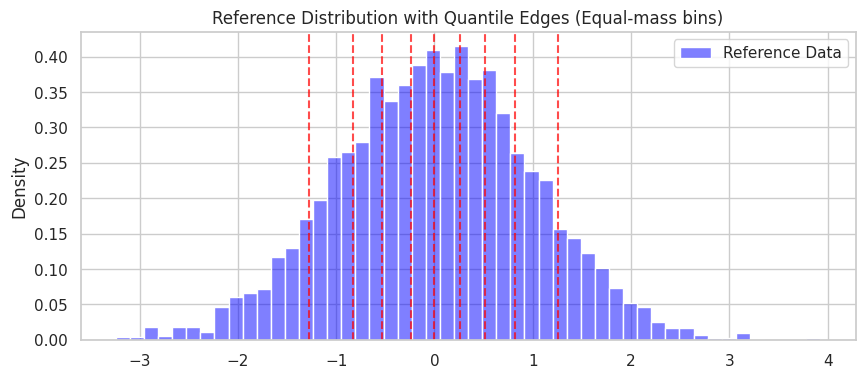

Calculated 10 bins. Edges (interior): [-1.28 -0.83 -0.53 -0.24 -0.    0.26  0.51  0.82  1.26]


In [6]:
# Invocation & Visualisation
edges = sketch_quantile_edges(example_sketch, n_bins=10)

plt.figure(figsize=(10, 4))
sns.histplot(ref_data, bins=50, color='blue', alpha=0.5, stat='density', label='Reference Data')
for edge in edges[1:-1]: # ignore inf
    plt.axvline(edge, color='red', linestyle='--', alpha=0.7)
plt.title("Reference Distribution with Quantile Edges (Equal-mass bins)")
plt.legend()
plt.show()

print(f"Calculated {len(edges)-1} bins. Edges (interior): {np.round(edges[1:-1], 2)}")

## 3 · Kolmogorov-Smirnov (KS) Test
**Concept:** The KS test measures the maximum vertical distance between the cumulative curves of two distributions. If the new data is very different from the reference, the gap between their curves will be large.

- **Statistic:** The maximum gap size (closer to 0 is better).


In [7]:
def compute_ks(
    reference_sketch: kll_floats_sketch,
    production_values: np.ndarray,
) -> dict[str, float]:
    """Compute approximate KS distance between a KLL reference CDF
    and the empirical production CDF.
    """

    production_values = np.asarray(production_values, dtype=float)
    production_values = production_values[np.isfinite(production_values)]

    if production_values.size == 0:
        return {"statistic": 0.0}

    # Unique production values are the points where the empirical
    # production CDF changes.
    split_points, counts = np.unique(
        production_values,
        return_counts=True,
    )

    n = production_values.size

    # Production CDF immediately before each split point: F(x-)
    production_cdf_before = (
        np.cumsum(counts) - counts
    ) / n

    # Production CDF at each split point: F(x)
    production_cdf_at = (
        np.cumsum(counts)
    ) / n

    # Reference CDF immediately before each split point.
    reference_cdf_before = np.asarray(
        reference_sketch.get_cdf(
            split_points.tolist(),
            inclusive=False,
        ),
        dtype=float,
    )[:-1]

    # Reference CDF at each split point.
    reference_cdf_at = np.asarray(
        reference_sketch.get_cdf(
            split_points.tolist(),
            inclusive=True,
        ),
        dtype=float,
    )[:-1]

    # KS distance = sup_x |F_reference(x) - F_production(x)|.
    #
    # We evaluate both sides of every empirical CDF jump.
    statistic = max(
        np.max(
            np.abs(
                production_cdf_before - reference_cdf_before
            )
        ),
        np.max(
            np.abs(
                production_cdf_at - reference_cdf_at
            )
        ),
    )

    return {"statistic": float(statistic)}

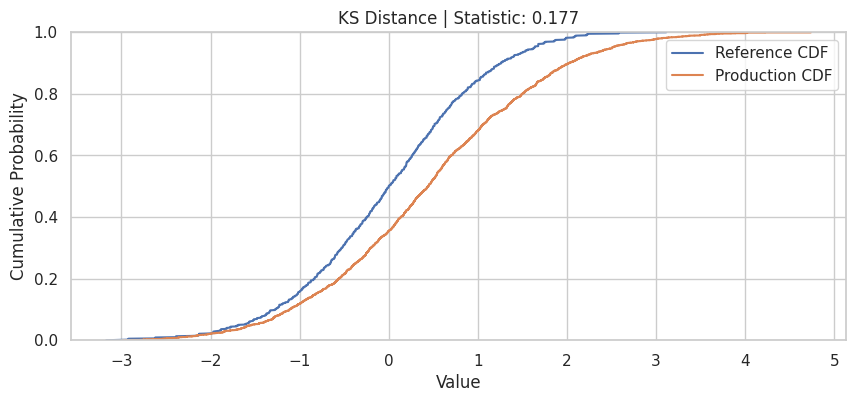

KS Result: {'statistic': 0.17699999999999994}


In [8]:
# Invocation & Visualisation
ks_res = compute_ks(example_sketch, prod_data)

# For visualization, we plot the CDFs
ranks = np.linspace(0, 1, 1000).tolist()
ref_cdf_vals = example_sketch.get_quantiles(ranks)

plt.figure(figsize=(10, 4))
plt.plot(
    ref_cdf_vals,
    ranks,
    label="Reference CDF",
)
sns.ecdfplot(
    prod_data,
    label="Production CDF",
)
plt.title(
    f"KS Distance | Statistic: {ks_res['statistic']:.3f}"
)
plt.xlabel("Value")
plt.ylabel("Cumulative Probability")
plt.legend()
plt.show()

print("KS Result:", ks_res)

## 4 · Population Stability Index (PSI)
**Concept:** PSI compares the percentage of data in each of our buckets (defined earlier) between the reference and the new data. If a bucket used to hold 10% of the data and now holds 25%, PSI goes up.

- **< 0.10**: Safe, no significant shift.
- **0.10 to 0.25**: Moderate shift, investigate.
- **> 0.25**: Significant shift, take action.

In [9]:
def compute_psi(
    reference_sketch: kll_floats_sketch,
    production_values: np.ndarray,
    n_bins: int = PSI_BINS,
    epsilon: float = 1e-8, # small value added to each proportion to prevent mathematical problems with zero.
) -> float:
    """Compute PSI using KLL-derived quantile bins."""

    edges = sketch_quantile_edges(reference_sketch, n_bins)
    ref_proportions = np.full(n_bins, 1.0 / n_bins)

    counts, _ = np.histogram(production_values, bins=edges)
    prod_proportions = counts / counts.sum() if counts.sum() > 0 else ref_proportions

    ref_proportions = ref_proportions + epsilon
    prod_proportions = prod_proportions + epsilon

    psi = float(np.sum((prod_proportions - ref_proportions) * np.log(prod_proportions / ref_proportions)))

    return psi

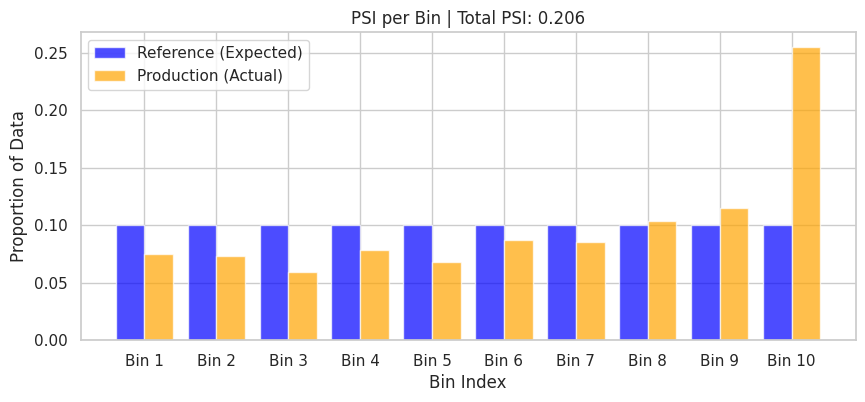

Calculated PSI: 0.2059


In [10]:
# Invocation & Visualisation
psi_val = compute_psi(example_sketch, prod_data, n_bins=10)

edges = sketch_quantile_edges(example_sketch, n_bins=10)
ref_props = np.full(10, 1.0 / 10)
prod_counts, _ = np.histogram(prod_data, bins=edges)
prod_props = prod_counts / prod_counts.sum()

x = np.arange(10)
plt.figure(figsize=(10, 4))
plt.bar(x - 0.2, ref_props, 0.4, label='Reference (Expected)', color='blue', alpha=0.7)
plt.bar(x + 0.2, prod_props, 0.4, label='Production (Actual)', color='orange', alpha=0.7)
plt.title(f"PSI per Bin | Total PSI: {psi_val:.3f}")
plt.xlabel("Bin Index")
plt.ylabel("Proportion of Data")
plt.xticks(x, [f"Bin {i+1}" for i in x])
plt.legend()
plt.show()

print(f"Calculated PSI: {psi_val:.4f}")

## 5 · Hellinger Distance
**Concept:** Hellinger distance is another way to measure how two probability distributions differ. It calculates the overlap between the distributions in our buckets.
It gives a clean score between 0 and 1, where 0 means identical and 1 means they share absolutely no values.

In [11]:
def compute_hellinger(
    reference_sketch: kll_floats_sketch,
    production_values: np.ndarray,
    n_bins: int = PSI_BINS,
    epsilon: float = 1e-8,
) -> float:
    """Compute Hellinger distance using KLL-derived quantile bins."""

    edges = sketch_quantile_edges(reference_sketch, n_bins)
    ref_proportions = np.full(n_bins, 1.0 / n_bins)

    counts, _ = np.histogram(production_values, bins=edges)
    prod_proportions = counts / counts.sum() if counts.sum() > 0 else ref_proportions

    ref_proportions = ref_proportions + epsilon
    prod_proportions = prod_proportions + epsilon
    ref_proportions /= ref_proportions.sum()
    prod_proportions /= prod_proportions.sum()

    hellinger = float(
        np.sqrt(np.sum((np.sqrt(ref_proportions) - np.sqrt(prod_proportions)) ** 2)) / np.sqrt(2)
    )

    return hellinger

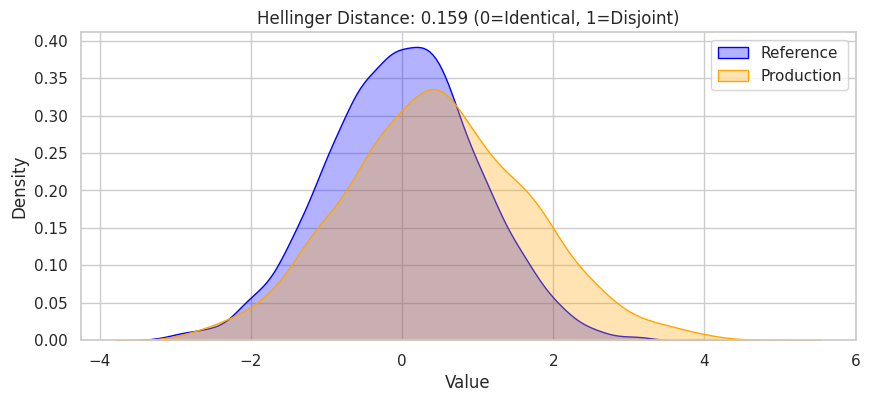

Calculated Hellinger Distance: 0.1593


In [12]:
# Invocation & Visualisation
hellinger_val = compute_hellinger(example_sketch, prod_data, n_bins=10)

plt.figure(figsize=(10, 4))
sns.kdeplot(ref_data, fill=True, label='Reference', color='blue', alpha=0.3)
sns.kdeplot(prod_data, fill=True, label='Production', color='orange', alpha=0.3)
plt.title(f"Hellinger Distance: {hellinger_val:.3f} (0=Identical, 1=Disjoint)")
plt.xlabel("Value")
plt.ylabel("Density")
plt.legend()
plt.show()

print(f"Calculated Hellinger Distance: {hellinger_val:.4f}")

## 6 · Combined Variable Monitor
**Concept:** A convenient wrapper that applies all the above metrics, along with missing data checks, to a single variable.

In [13]:
def compute_missing_rate(values: pd.Series) -> float:
    """Return the fraction of NaN values in a Series."""

    return float(values.isna().mean())

def monitor_variable(
    name: str,
    reference_sketch: kll_floats_sketch,
    production_values: np.ndarray,
    missing_rate: float,
) -> dict:
    """Compute all drift and quality metrics for one variable."""

    ks_result = compute_ks(reference_sketch, production_values)
    psi_value = compute_psi(reference_sketch, production_values)
    hellinger_value = compute_hellinger(reference_sketch, production_values)

    return {
        "name": name,
        "missing_rate": missing_rate,
        "ks": ks_result,
        "psi": psi_value,
        "hellinger": hellinger_value,
    }

In [14]:
# Invocation
summary = monitor_variable("example_feature", example_sketch, prod_data, missing_rate=0.0)
print(json.dumps(summary, indent=2))

{
  "name": "example_feature",
  "missing_rate": 0.0,
  "ks": {
    "statistic": 0.17699999999999994
  },
  "psi": 0.20585828845038268,
  "hellinger": 0.15932345623311783
}


## 7 · Load Baseline & Model

In [15]:
baseline = json.loads((BASELINES_DIR / "baseline.json").read_text())
model = joblib.load(DATA_DIR / "model.joblib")
print(f"Baseline features: {list(baseline['features'].keys())}")

Baseline features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']


## 8 · Load Production Batch & Inject Drift (Optional)

In [16]:
X_prod = pd.read_parquet(DATA_DIR / "X_test.parquet")

# --- Optional: inject synthetic drift to test monitoring ---
# Uncomment to shift MedInc by +2 and add 5% missing values to AveRooms
# X_prod["MedInc"] = X_prod["MedInc"] + 2.0
# X_prod.loc[X_prod.sample(frac=0.05, random_state=RANDOM_STATE).index, "AveRooms"] = np.nan

print(f"Production batch: {X_prod.shape[0]:,} rows")
X_prod.head()

Production batch: 4,128 rows


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,1.6812,25.0,4.192201,1.022284,1392.0,3.877437,36.06,-119.01
1,2.5313,30.0,5.039384,1.193493,1565.0,2.679795,35.14,-119.46
2,3.4801,52.0,3.977155,1.185877,1310.0,1.360332,37.80,-122.44
3,5.7376,17.0,6.163636,1.020202,1705.0,3.444444,34.28,-118.72
4,3.7250,34.0,5.492991,1.028037,1063.0,2.483645,36.62,-121.93


## 9 · Run Inference

In [17]:
# Fill NaNs with median (same as training pre-process assumption) for prediction
X_prod_filled = X_prod.fillna(X_prod.median(numeric_only=True))
predictions = model.predict(X_prod_filled).astype(np.float32)
print(f"Predictions: mean={predictions.mean():.4f}  std={predictions.std():.4f}")

Predictions: mean=2.0594  std=0.9750


## 10 · Compute monitoring metrics across all features

In [18]:
monitoring_results: list[dict] = []

for col in X_prod.columns:
    ref_sketch = base64_to_sketch(baseline["features"][col]["sketch_b64"])
    series = X_prod[col]
    clean_values = series.dropna().to_numpy(dtype=np.float32)
    missing = compute_missing_rate(series)

    result = monitor_variable(col, ref_sketch, clean_values, missing)
    monitoring_results.append(result)

# Prediction drift
pred_ref_sketch = base64_to_sketch(baseline["prediction"]["sketch_b64"])
pred_result = monitor_variable(
    "prediction",
    pred_ref_sketch,
    predictions,
    missing_rate=0.0,   # predictions are always present
)
monitoring_results.append(pred_result)

print(f"Monitored {len(monitoring_results)} variables (features + prediction)")

Monitored 9 variables (features + prediction)


### Conventions and Thresholds Explained

The thresholds used in this report are based on common statistical practices and established conventions used in ML monitoring and MLOps platforms, including **Fiddler AI**, **Evidently AI**, and **H2O MLOps**:

1. **Number of Bins (10):** Common practical convention for Population Stability Index (PSI). Ten bins are frequently used for PSI-based monitoring, although the appropriate binning strategy depends on the data and use case.

   - *Source:* **H2O MLOps** - [Key Terms](https://docs.h2o.ai/mlops/v1.0.22/key-terms) (uses a maximum of 10 equal bins for PSI).
   - *Source:* **Fiddler AI** - [Measuring Data Drift with PSI](https://www.fiddler.ai/blog/measuring-data-drift-population-stability-index) (illustrates PSI using ten bins and discusses binning strategies).

2. **PSI Thresholds (`<0.10` safe, `0.10 - 0.25` moderate, `≥0.25` significant):** Widely used practical rules of thumb for interpreting PSI, particularly in credit scoring and model monitoring. These are empirical conventions rather than statistically derived universal thresholds.

   - *Source:* **Fiddler AI** - [Measuring Data Drift with PSI](https://www.fiddler.ai/blog/measuring-data-drift-population-stability-index) (documents the commonly used `<0.10`, `0.10 - 0.20`, and `>0.20` rules of thumb).
   - *Source:* **Evidently AI** - [Customize Data Drift](https://docs.evidentlyai.com/metrics/customize_data_drift) (uses `0.1` as the default PSI drift threshold).

3. **KS Threshold (p-value `<0.05`):** A conventional statistical significance level for hypothesis testing. For the two-sample KS test, `p < 0.05` is commonly used to reject the null hypothesis that the samples come from the same distribution.

   - *Source:* **SciPy Documentation** - [scipy.stats.ks_2samp](https://docs.scipy.org/doc/scipy-1.15.1/reference/generated/scipy.stats.ks_2samp.html) (demonstrates the `0.05` significance threshold).
   - *Source:* **Evidently AI** - [Customize Data Drift](https://docs.evidentlyai.com/metrics/customize_data_drift) (uses `0.05` as the default KS drift threshold).

4. **Hellinger Threshold (`0.1`):** A practical threshold used by MLOps tooling to detect distribution drift. Evidently uses `0.1` as its default Hellinger distance threshold.

   - *Source:* **Evidently AI** - [Customize Data Drift](https://docs.evidentlyai.com/metrics/customize_data_drift) (default Hellinger drift threshold is `0.1`).

In [19]:
ALERT_PSI = 0.10
ALERT_KS = 0.05       # KS statistic threshold
ALERT_HELLINGER = 0.1
ALERT_MISSING = 0.02  # flag if > 2% missing


def drift_flag(result: dict) -> str:
    """Return an alert if any metric exceeds its threshold."""

    if (
        result["psi"] >= ALERT_PSI
        or result["ks"]["statistic"] >= ALERT_KS
        or result["hellinger"] >= ALERT_HELLINGER
        or result["missing_rate"] > ALERT_MISSING
    ):
        return "ALERT"

    return "OK"


print(
    f"{'Variable':<20} {'Missing':>8} {'KS stat':>9} "
    f"{'PSI':>8} {'Hellinger':>10} {'Status':>8}"
)

print("-" * 70)

for r in monitoring_results:
    print(
        f"{r['name']:<20} "
        f"{r['missing_rate']:>8.4f} "
        f"{r['ks']['statistic']:>9.4f} "
        f"{r['psi']:>8.4f} "
        f"{r['hellinger']:>10.4f} "
        f"{drift_flag(r):>8}"
    )

Variable              Missing   KS stat      PSI  Hellinger   Status
----------------------------------------------------------------------
MedInc                 0.0000    0.0253   0.0040     0.0223       OK
HouseAge               0.0000    0.0119   0.0039     0.0220       OK
AveRooms               0.0000    0.0319   0.0040     0.0224       OK
AveBedrms              0.0000    0.0274   0.0021     0.0161       OK
Population             0.0000    0.0187   0.0010     0.0112       OK
AveOccup               0.0000    0.0174   0.0053     0.0257       OK
Latitude               0.0000    0.0182   0.0022     0.0167       OK
Longitude              0.0000    0.0220   0.0036     0.0211       OK
prediction             0.0000    0.0171   0.0025     0.0177       OK


## 12 · Save Report to JSON

In [20]:
report = {
    "run_at": datetime.now(tz=timezone.utc).isoformat(),
    "batch_size": len(X_prod),
    "thresholds": {
        "psi_alert": ALERT_PSI,
        "ks_p_value_alert": ALERT_KS,
        "hellinger_alert": ALERT_HELLINGER,
        "missing_rate_alert": ALERT_MISSING,
    },
    "variables": [
        {**r, "status": drift_flag(r)} for r in monitoring_results
    ],
}

report_path = REPORTS_DIR / "monitoring_report.json"
report_path.write_text(json.dumps(report, indent=2))
print(f"Report saved -> {report_path}")

Report saved -> reports/monitoring_report.json
